In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../figures", exist_ok=True)

In [2]:
df = pd.read_csv("../results/results_summary.csv")

# Pivot so each row is a unique postprocessing config with both mAP values
id_cols = ["model", "cell_type", "agg", "fs", "norm1", "norm2"]
wide = df.pivot_table(index=id_cols, columns="task", values="mAP").reset_index()
wide.columns.name = None
wide = wide.rename(columns={"replicate": "replicate_mAP", "moa": "moa_mAP"})

# Build a label for the postprocessing pipeline
wide["pipeline"] = (
    "agg=" + wide["agg"].astype(str)
    + " fs=" + wide["fs"].astype(str)
    + " " + wide["norm1"].astype(str)
    + "/" + wide["norm2"].astype(str)
)

wide.head()

,model,cell_type,agg,fs,norm1,norm2,moa_mAP,replicate_mAP,pipeline
0,cellprofiler,A549,median,0,PCA,mad_robustize,0.139952,0.290066,agg=median fs=0 PCA/mad_robustize
1,cellprofiler,A549,median,0,PCA,standardize,0.106037,0.205582,agg=median fs=0 PCA/standardize
2,cellprofiler,A549,median,0,ZCA,mad_robustize,0.147821,0.311136,agg=median fs=0 ZCA/mad_robustize
3,cellprofiler,A549,median,0,ZCA,standardize,0.109444,0.215408,agg=median fs=0 ZCA/standardize
4,cellprofiler,A549,median,0,mad_robustize,none,0.138949,0.247760,agg=median fs=0 mad_robustize/none


In [3]:
MODEL_ORDER = [
    "cellprofiler", "deepprofiler",
    "dino", "dino_masked",
    "subcell_mae", "subcell_mae_masked",
    "subcell_vit", "subcell_vit_masked",
]


def pareto_mask(x, y):
    """Return boolean mask for points on the Pareto frontier (maximize both)."""
    is_pareto = np.ones(len(x), dtype=bool)
    for i in range(len(x)):
        for j in range(len(x)):
            if i != j and x[j] >= x[i] and y[j] >= y[i] and (x[j] > x[i] or y[j] > y[i]):
                is_pareto[i] = False
                break
    return is_pareto

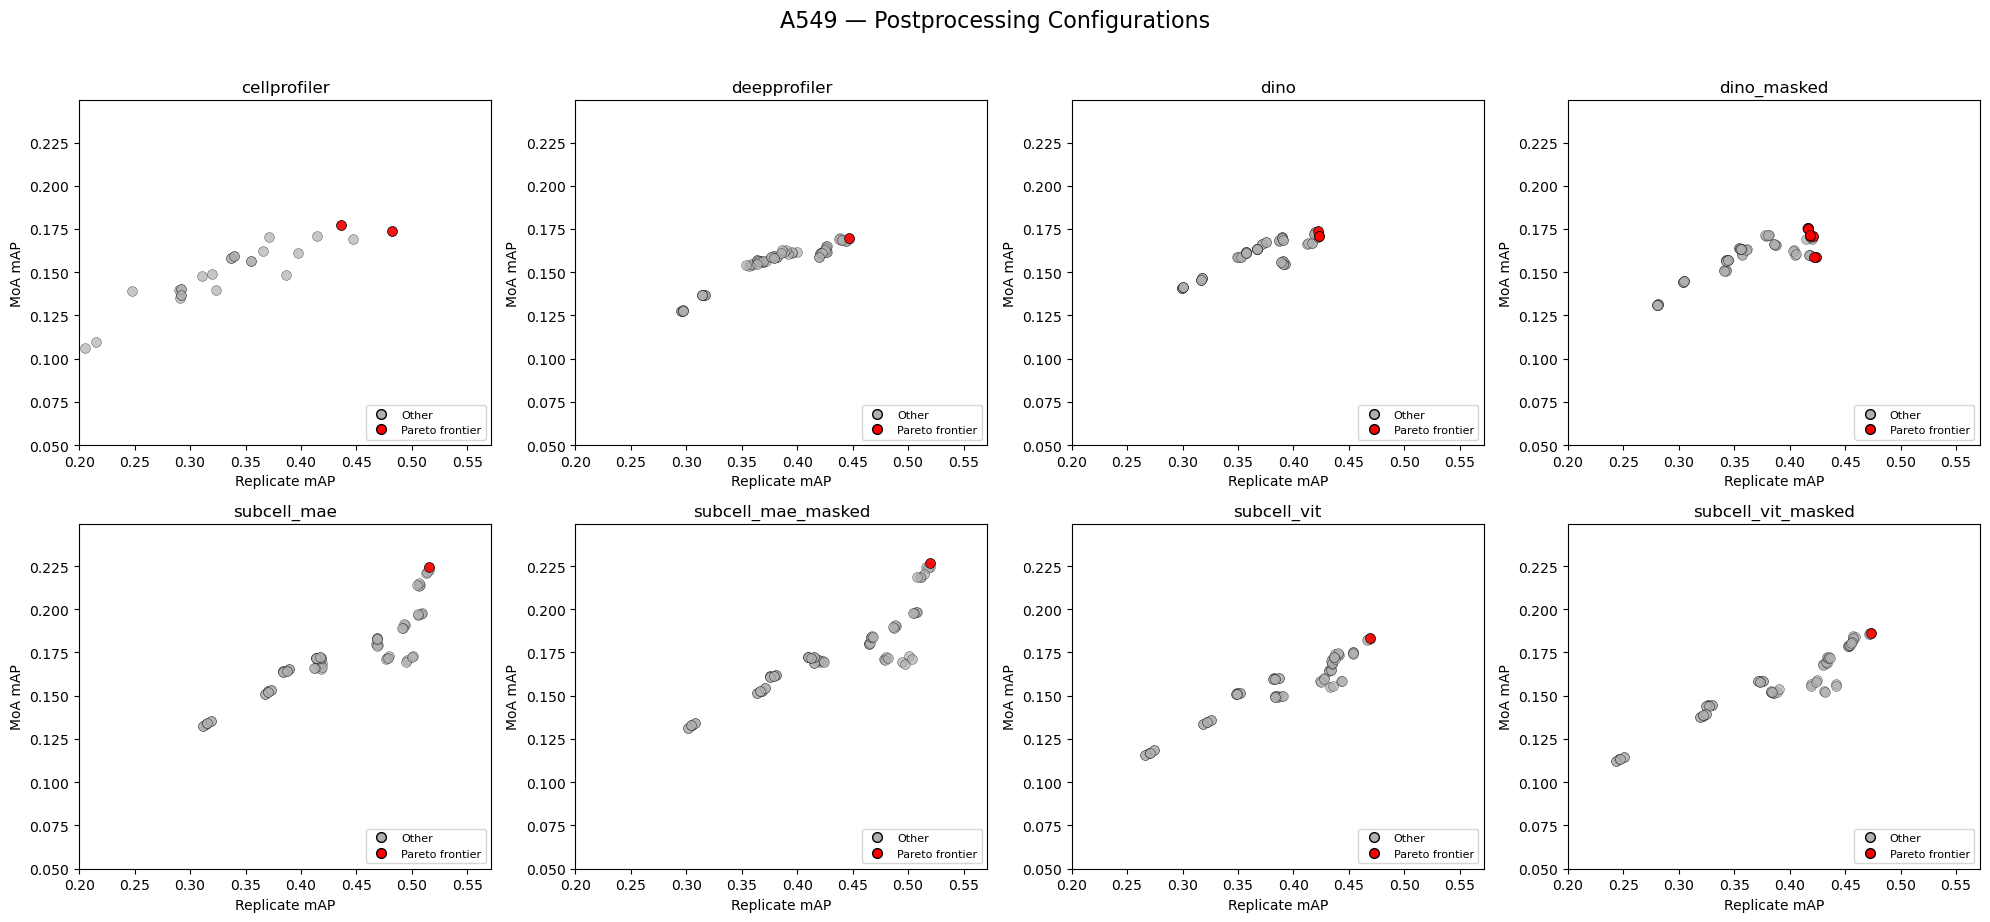

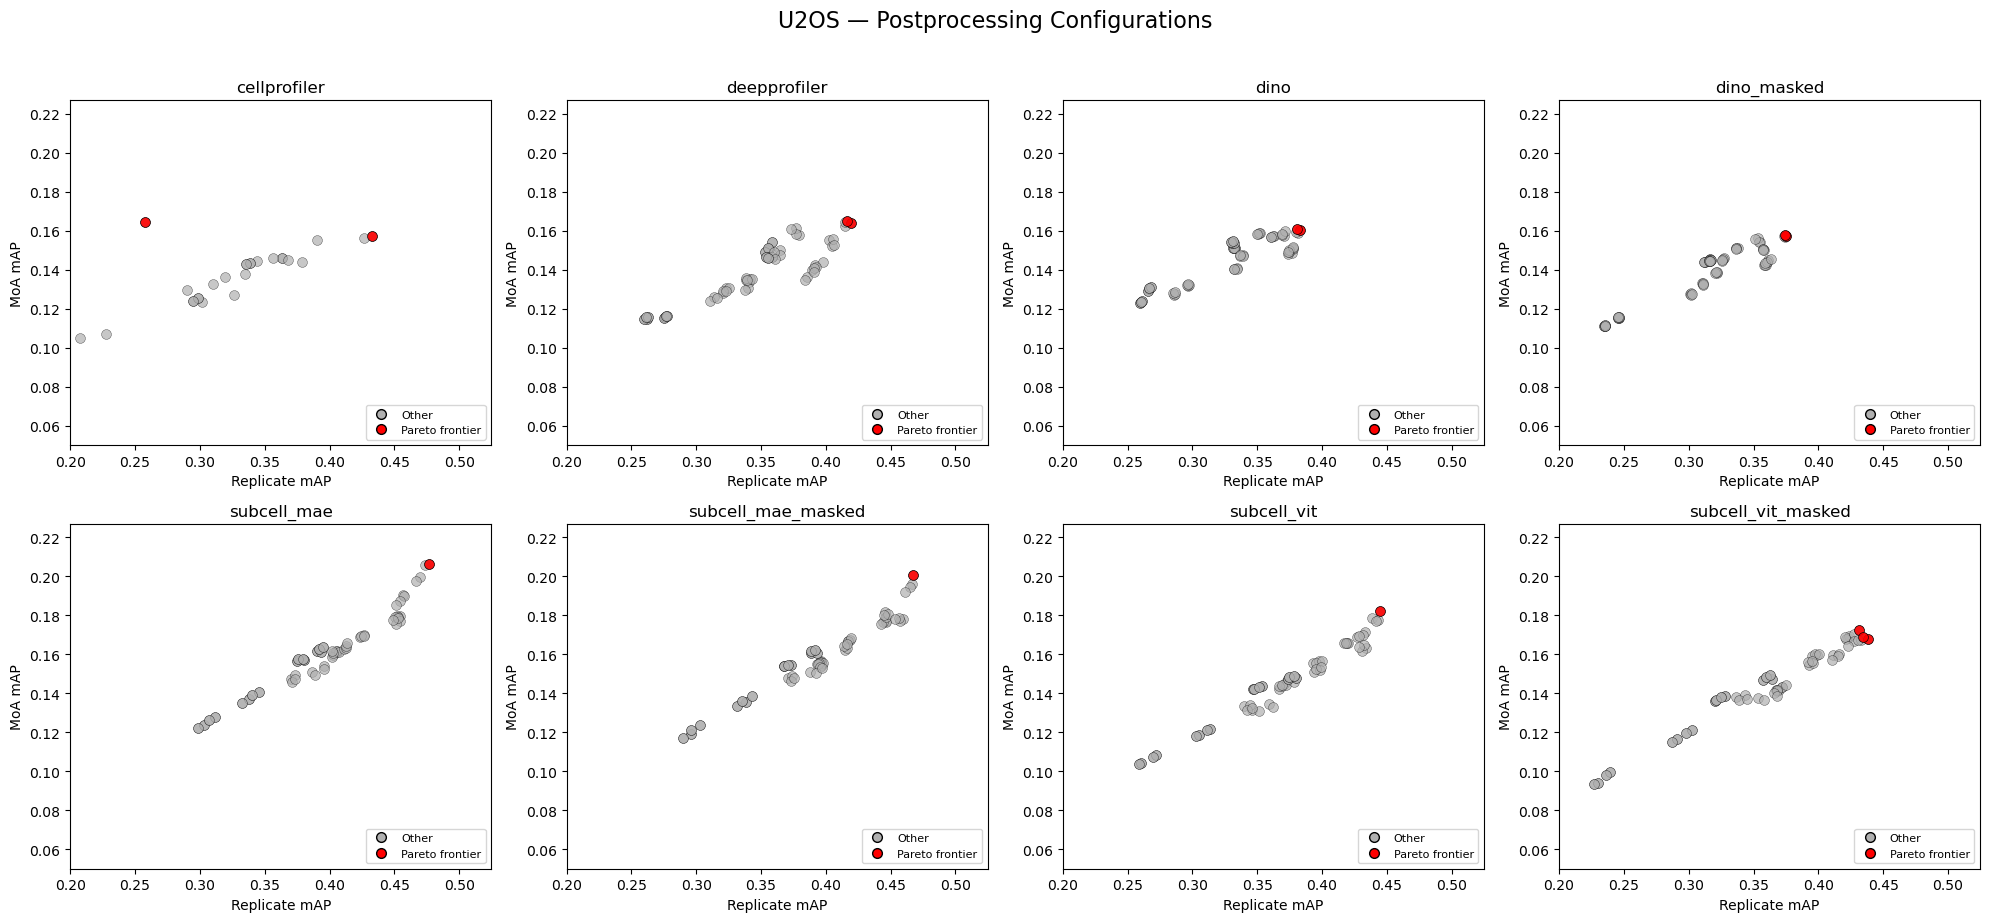

In [4]:
from matplotlib.lines import Line2D

for cell_type in sorted(wide["cell_type"].unique()):
    ct_df = wide[wide["cell_type"] == cell_type]
    models_present = [m for m in MODEL_ORDER if m in ct_df["model"].unique()]
    n = len(models_present)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                             squeeze=False)
    fig.suptitle(f"{cell_type} — Postprocessing Configurations", fontsize=16, y=1.02)

    # Shared axis limits across all subplots for this cell type
    x_max = ct_df["replicate_mAP"].max() * 1.1
    y_max = ct_df["moa_mAP"].max() * 1.1

    for idx, model in enumerate(models_present):
        ax = axes[idx // ncols, idx % ncols]
        mdf = ct_df[ct_df["model"] == model].reset_index(drop=True)

        x = mdf["replicate_mAP"].values
        y = mdf["moa_mAP"].values
        on_front = pareto_mask(x, y)

        # All points in gray
        ax.scatter(x, y, c="#b0b0b0", alpha=0.7, edgecolors="k",
                   linewidths=0.3, s=50, zorder=1)
        # Pareto frontier points in red
        ax.scatter(x[on_front], y[on_front], c="red", alpha=0.9,
                   edgecolors="k", linewidths=0.5, s=50, zorder=2)

        ax.set_title(model, fontsize=12)
        ax.set_xlabel("Replicate mAP")
        ax.set_ylabel("MoA mAP")
        ax.set_xlim(0.2, x_max)
        ax.set_ylim(0.05, y_max)

        legend_handles = [
            Line2D([0], [0], marker="o", color="w", markerfacecolor="#b0b0b0",
                   markeredgecolor="k", markersize=7, label="Other"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
                   markeredgecolor="k", markersize=7, label="Pareto frontier"),
        ]
        ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

    # Hide unused axes
    for idx in range(n, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    fig.tight_layout()
    fig.savefig(f"../figures/pareto_frontiers_{cell_type}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
# Collect all Pareto frontier rows
pareto_rows = []
for (cell_type, model), grp in wide.groupby(["cell_type", "model"]):
    x = grp["replicate_mAP"].values
    y = grp["moa_mAP"].values
    mask = pareto_mask(x, y)
    pareto_rows.append(grp[mask])

pareto_df = pd.concat(pareto_rows, ignore_index=True)
pareto_df = pareto_df.sort_values(["cell_type", "model", "replicate_mAP"], ascending=[True, True, False])

display_cols = ["cell_type", "model", "agg", "fs", "norm1", "norm2", "replicate_mAP", "moa_mAP"]
pareto_df[display_cols].round(4)

,cell_type,model,agg,fs,norm1,norm2,replicate_mAP,moa_mAP
1,A549,cellprofiler,median,1,mad_robustize,none,0.4824,0.1740
0,A549,cellprofiler,median,1,PCAcor,mad_robustize,0.4360,0.1771
2,A549,deepprofiler,mean,1,PCAcor,mad_robustize,0.4470,0.1697
4,A549,dino,median,0,PCAcor,standardize,0.4233,0.1710
5,A549,dino,median,1,PCAcor,standardize,0.4233,0.1710
3,A549,dino,mean,1,PCA,mad_robustize,0.4218,0.1737
6,A549,dino_masked,mean,0,mad_robustize,none,0.4238,0.1586
11,A549,dino_masked,median,0,mad_robustize,none,0.4219,0.1588
7,A549,dino_masked,mean,1,PCA,mad_robustize,0.4214,0.1710
10,A549,dino_masked,median,0,PCAcor,standardize,0.4184,0.1712


In [6]:
# Best postprocessing pipeline per model family (selected from Pareto frontiers across cell types)
# DeepProfiler: TBD pending A549 results
best_configs = [
    {"model": "cellprofiler",       "agg": "median", "fs": 1, "norm1": "mad_robustize", "norm2": "none"},
    {"model": "dino",               "agg": "mean",   "fs": 1, "norm1": "PCA",           "norm2": "mad_robustize"},
    {"model": "subcell_mae_masked", "agg": "median", "fs": 0, "norm1": "PCA",           "norm2": "standardize"},
    {"model": "deepprofiler", "agg": "mean", "fs": 1, "norm1": "PCAcor",           "norm2": "mad_robustize"}
]

best_df = pd.DataFrame(best_configs)

# Filter the wide table to only the best config rows (across all cell types)
selected = wide.merge(best_df, on=["model", "agg", "fs", "norm1", "norm2"])
selected = selected.sort_values(["cell_type", "model"]).reset_index(drop=True)

display_cols = ["cell_type", "model", "agg", "fs", "norm1", "norm2", "replicate_mAP", "moa_mAP"]
selected[display_cols].round(4)

,cell_type,model,agg,fs,norm1,norm2,replicate_mAP,moa_mAP
0,A549,cellprofiler,median,1,mad_robustize,none,0.4824,0.1740
1,A549,deepprofiler,mean,1,PCAcor,mad_robustize,0.4470,0.1697
2,A549,dino,mean,1,PCA,mad_robustize,0.4218,0.1737
3,A549,subcell_mae_masked,median,0,PCA,standardize,0.5196,0.2267
4,U2OS,cellprofiler,median,1,mad_robustize,none,0.4329,0.1573
5,U2OS,deepprofiler,mean,1,PCAcor,mad_robustize,0.4164,0.1651
6,U2OS,dino,mean,1,PCA,mad_robustize,0.3827,0.1603
7,U2OS,subcell_mae_masked,median,0,PCA,standardize,0.4671,0.2009


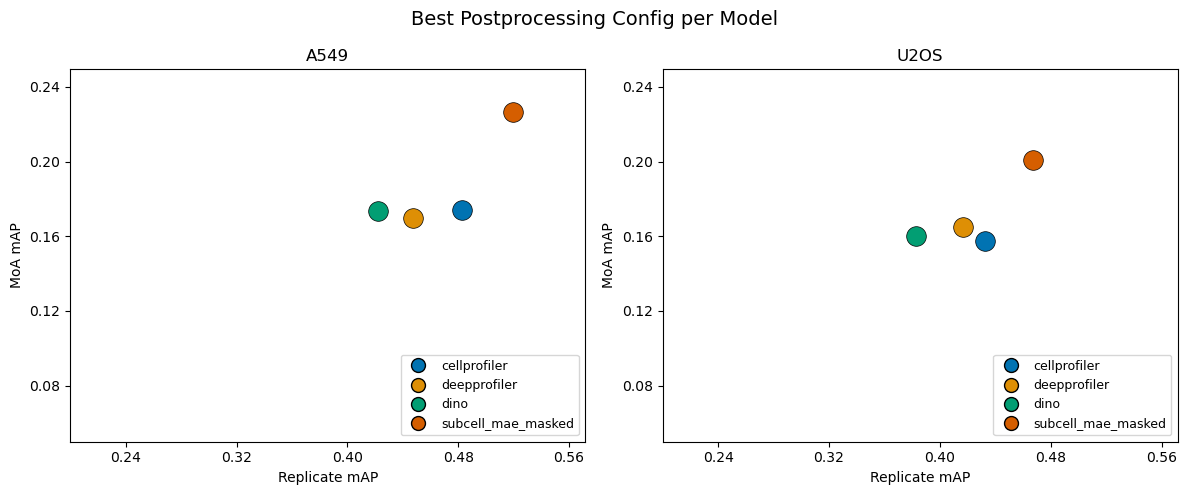

In [7]:
# Seaborn colorblind palette — consistent with per_moa_analysis.ipynb
BEST_MODEL_COLORS = {
    "cellprofiler":       "#0173b2",  # blue
    "deepprofiler":       "#de8f05",  # amber
    "dino":               "#029e73",  # teal
    "subcell_mae_masked": "#d55e00",  # vermillion
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)
fig.suptitle("Best Postprocessing Config per Model", fontsize=14)

for col_idx, cell_type in enumerate(sorted(selected["cell_type"].unique())):
    ax = axes[0, col_idx]
    ct = selected[selected["cell_type"] == cell_type]

    for _, row in ct.iterrows():
        ax.scatter(row["replicate_mAP"], row["moa_mAP"],
                   c=BEST_MODEL_COLORS[row["model"]], s=200,
                   edgecolors="k", linewidths=0.5, zorder=2)

    ax.set_title(cell_type, fontsize=12)
    ax.set_xlabel("Replicate mAP")
    ax.set_ylabel("MoA mAP")
    ax.set_xlim(0.2, selected["replicate_mAP"].max() * 1.1)
    ax.set_ylim(0.05, selected["moa_mAP"].max() * 1.1)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
               markeredgecolor="k", markersize=10, label=m)
        for m, c in BEST_MODEL_COLORS.items()
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=9)

fig.tight_layout()
fig.savefig("../figures/best_config_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()

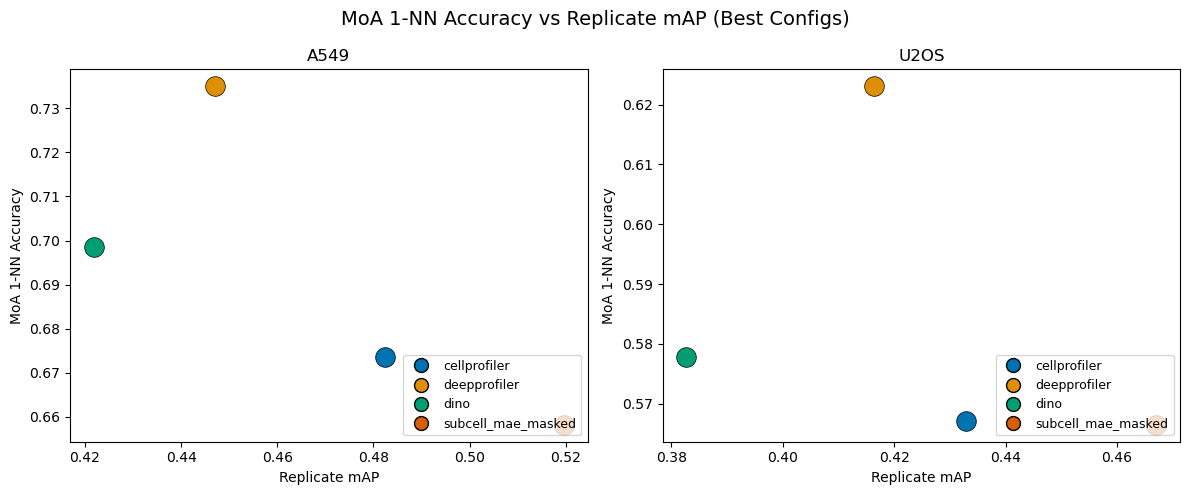

In [8]:
# Scatter: MoA 1-NN Accuracy (y) vs Replicate mAP (x) for best configs
rep_cols = id_cols + ["mAP"]
moa_nn_cols = id_cols + ["nn_k1"]

rep_data = df[df["task"] == "replicate"][rep_cols].rename(columns={"mAP": "replicate_mAP"})
moa_nn_data = df[df["task"] == "moa"][moa_nn_cols].rename(columns={"nn_k1": "moa_nn_k1"})
scatter_data = rep_data.merge(moa_nn_data, on=id_cols)
scatter_data = scatter_data.merge(best_df, on=["model", "agg", "fs", "norm1", "norm2"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("MoA 1-NN Accuracy vs Replicate mAP (Best Configs)", fontsize=14)

for col_idx, cell_type in enumerate(sorted(scatter_data["cell_type"].unique())):
    ax = axes[col_idx]
    ct = scatter_data[scatter_data["cell_type"] == cell_type]
    for _, row in ct.iterrows():
        ax.scatter(row["replicate_mAP"], row["moa_nn_k1"],
                   c=BEST_MODEL_COLORS[row["model"]], s=200,
                   edgecolors="k", linewidths=0.5, zorder=2)
    ax.set_title(cell_type, fontsize=12)
    ax.set_xlabel("Replicate mAP")
    ax.set_ylabel("MoA 1-NN Accuracy")

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
               markeredgecolor="k", markersize=10, label=m)
        for m, c in BEST_MODEL_COLORS.items()
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=9)

fig.tight_layout()
fig.savefig("../figures/moa_nn_vs_replicate_map.pdf", dpi=300, bbox_inches="tight")
plt.show()

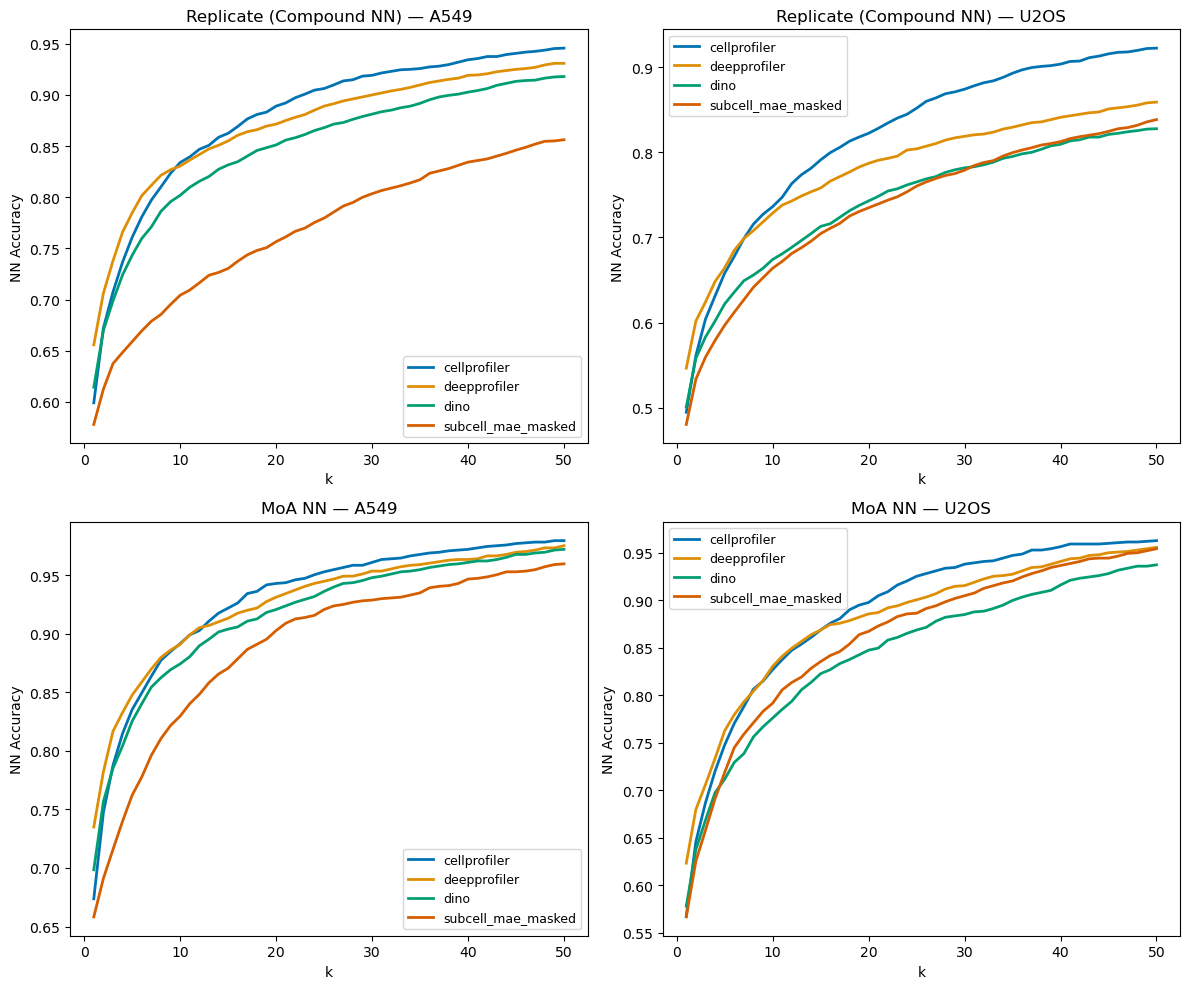

In [9]:
# k-NN accuracy curves (k=1..50) for best configs
# Rows: Replicate (compound NN) / MoA (MoA NN), Columns: cell type
nn_cols = [f"nn_k{k}" for k in range(1, 51)]
ks = np.arange(1, 51)

best_data = df.merge(best_df, on=["model", "agg", "fs", "norm1", "norm2"])
cell_types = sorted(best_data["cell_type"].unique())
task_labels = {"replicate": "Replicate (Compound NN)", "moa": "MoA NN"}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row_idx, task in enumerate(["replicate", "moa"]):
    for col_idx, cell_type in enumerate(cell_types):
        ax = axes[row_idx, col_idx]
        subset = best_data[(best_data["task"] == task) & (best_data["cell_type"] == cell_type)]
        for _, row in subset.iterrows():
            vals = row[nn_cols].values.astype(float)
            ax.plot(ks, vals, color=BEST_MODEL_COLORS[row["model"]],
                    label=row["model"], linewidth=2)
        ax.set_title(f"{task_labels[task]} — {cell_type}", fontsize=12)
        ax.set_xlabel("k")
        ax.set_ylabel("NN Accuracy")
        ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig("../figures/knn_accuracy_curves.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
subcell_moa_maps = pd.read_csv("../results/map_per_group/subcell_mae_masked__U2OS__median__fs0__PCA__standardize__moa.csv")
subcell_moa_maps

subcell_moa_maps = pd.read_csv("../results/map_per_group/subcell_mae_masked__U2OS__median__fs0__PCA__standardize__moa.csv")
subcell_moa_maps

,moas,mean_average_precision,p_value,corrected_p_value,below_p,below_corrected_p
0,ALK tyrosine kinase receptor inhibitor,0.118713,0.074093,0.113224,False,False
1,ATM kinase inhibitor,0.124866,0.041796,0.068474,True,False
2,ATP channel blocker,0.118726,0.050695,0.081323,False,False
3,Aurora kinase inhibitor,0.901370,0.000100,0.000405,True,True
4,Bcr-Abl kinase inhibitor,0.025494,0.994801,1.000000,False,False
...,...,...,...,...,...,...
72,somatostatin receptor agonist,0.217214,0.002100,0.005389,True,True
73,sphingosine 1 phosphate receptor agonist,0.186428,0.004900,0.011096,True,True
74,src inhibitor,0.548606,0.000100,0.000405,True,True
75,tubulin polymerization inhibitor,0.663881,0.000100,0.000405,True,True
